# CSCE 636-600 Fall 2025 — Project 3  
**Student:** Vigya Awasthi (UIN: 136003991)  

## Problem Overview

The goal of this project is to build an accurate and stable predictor for the m-height of generator matrices. Each sample is described by the tuple \((n, k, m, P)\), where \(P\) is a real-valued matrix. The target is the scalar m-height associated with the generator matrix.

Compared to Project 1 and Project 2, this project uses:

- A larger training set DS-3 (56,365 samples), which contains the DS-2 training set as a subset.
- A deep learning based architecture in log2-space, designed to improve both accuracy and stability of predictions.
- Per-bucket models that specialize for each \((k, m)\) combination, together with an ensemble across different random seeds.

The main evaluation metric is the mean squared error of \(\log_2(\text{mHeight})\). Therefore, the model is trained directly in log2-space and focuses on minimizing the squared error there. This design is consistent with the model architectures highlighted in the instructor’s Project 2 summary.


In [8]:
# ============================================================
# Project 3 — Setup: mount, imports, config
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os, pickle, math, numpy as np
from collections import defaultdict, Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# ---- PATHS: UPDATE if your files are in a different folder ----
PATH_X = "/content/drive/MyDrive/DS-3-Train-n_k_m_P"
PATH_Y = "/content/drive/MyDrive/DS-3-Train-mHeights"

# Where to save Project 3 models
MODELS_DIR_DNN_P3 = os.path.join(os.path.dirname(PATH_X), "per_bucket_models_DNN_P3_project3-1")
os.makedirs(MODELS_DIR_DNN_P3, exist_ok=True)

print("Models will be saved under:", MODELS_DIR_DNN_P3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models will be saved under: /content/drive/MyDrive/per_bucket_models_DNN_P3_project3-1


In [9]:
# ============================================================
# Load DS-3 training set and basic cleaning
# ============================================================

with open(PATH_X, "rb") as f:
    X_all_raw = pickle.load(f)   # list of [n, k, m, P]
with open(PATH_Y, "rb") as f:
    y_all_raw = np.array(pickle.load(f), dtype=float)

print(f"Loaded {len(X_all_raw)} samples from DS-3.")

# Basic sanity mask: positive, finite m-heights
mask = np.isfinite(y_all_raw) & (y_all_raw > 0)
idx_good = np.where(mask)[0]

X_clean_v2 = [X_all_raw[i] for i in idx_good]
y_clean_v2 = y_all_raw[mask]

print(f"After cleaning: {len(X_clean_v2)} samples remain.")

# Bucket summary
km_to_idx_clean = defaultdict(list)
for i, (n, k, m, P) in enumerate(X_clean_v2):
    km_to_idx_clean[(k, m)].append(i)

print("Bucket sizes (k,m):")
for (k, m), idxs in sorted(km_to_idx_clean.items()):
    print(f"(k={k}, m={m}) -> {len(idxs)} samples")


Loaded 56365 samples from DS-3.
After cleaning: 56365 samples remain.
Bucket sizes (k,m):
(k=4, m=2) -> 5708 samples
(k=4, m=3) -> 5593 samples
(k=4, m=4) -> 5161 samples
(k=4, m=5) -> 3352 samples
(k=5, m=2) -> 6297 samples
(k=5, m=3) -> 5859 samples
(k=5, m=4) -> 3714 samples
(k=6, m=2) -> 13365 samples
(k=6, m=3) -> 7316 samples


## Exploratory Data Analysis of DS-3 targets

I first examined the distribution of the m-heights on the DS-3 training set. The raw m-heights are very skewed with a long right tail, while the distribution of \(\log_2(\text{mHeight})\) is much more regular and closer to a bell-shaped curve.

This confirms that working in log2-space is more numerically stable and better aligned with the evaluation metric (MSE on \(\log_2(\text{mHeight})\)). It also reduces the influence of extremely large m-heights and makes the deep learning optimization problem easier.


Total cleaned samples: 56365

=== Basic statistics of m-heights (original scale) ===
min: 2.0
p01: 6.666666666666668
p05: 17.5
p25: 86.52658024407907
median: 303.38591740013544
mean: 7584.601117642381
p75: 1646.5384615384617
p95: 26521.048571428586
p99: 120253.60000000239
max: 5570861.374998225


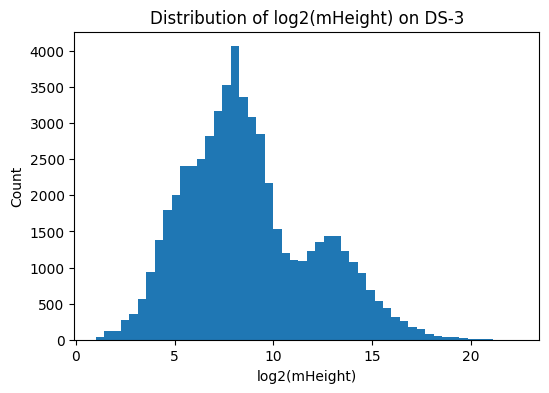

In [10]:
import numpy as np
import matplotlib.pyplot as plt

y_arr = np.array(y_clean_v2, dtype=float)
print(f"Total cleaned samples: {len(y_arr)}")

print("\n=== Basic statistics of m-heights (original scale) ===")
print("min:", np.min(y_arr))
print("p01:", np.percentile(y_arr, 1))
print("p05:", np.percentile(y_arr, 5))
print("p25:", np.percentile(y_arr, 25))
print("median:", np.median(y_arr))
print("mean:", np.mean(y_arr))
print("p75:", np.percentile(y_arr, 75))
print("p95:", np.percentile(y_arr, 95))
print("p99:", np.percentile(y_arr, 99))
print("max:", np.max(y_arr))

# log2 distribution
y_log = np.log2(np.maximum(1.0, y_arr))

plt.figure(figsize=(6,4))
plt.hist(y_log, bins=50)
plt.xlabel("log2(mHeight)")
plt.ylabel("Count")
plt.title("Distribution of log2(mHeight) on DS-3")
plt.show()


## Bucket Structure by (k, m)

The instructor suggested that the prediction difficulty and distribution of m-heights can depend strongly on the parameters \(k\) and \(m\). To respect this structure, I split the data into buckets indexed by \((k, m)\).

The plot and counts above show that:

- Some buckets, such as \((k=6, m=2)\), have many samples.
- Others, such as \((k=4, m=5)\) or \((k=5, m=4)\), have fewer samples and contain more extreme m-heights.

Instead of using one single global model, I train separate deep models for each \((k, m)\) bucket. This allows each model to specialize on the scale and difficulty of its own bucket and follows the mixture-of-experts style that performed well in earlier projects.


Bucket sizes for DS-3:
(k=4, m=2) -> N = 5708
(k=4, m=3) -> N = 5593
(k=4, m=4) -> N = 5161
(k=4, m=5) -> N = 3352
(k=5, m=2) -> N = 6297
(k=5, m=3) -> N = 5859
(k=5, m=4) -> N = 3714
(k=6, m=2) -> N = 13365
(k=6, m=3) -> N = 7316


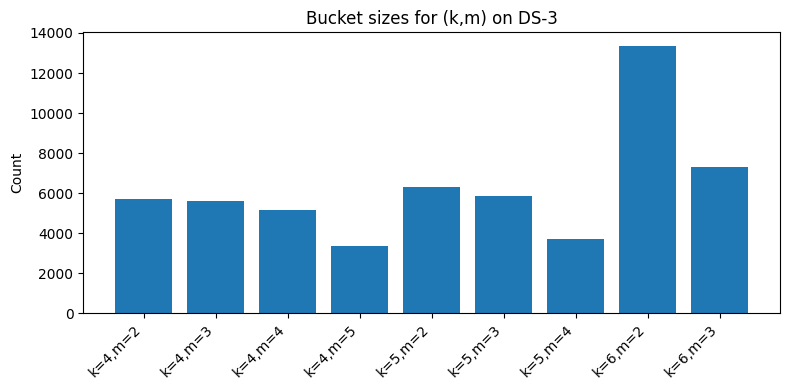

In [11]:
from collections import Counter

km_counts = { (k,m): len(idxs) for (k,m), idxs in km_to_idx_clean.items() }
print("Bucket sizes for DS-3:")
for (k,m), cnt in sorted(km_counts.items()):
    print(f"(k={k}, m={m}) -> N = {cnt}")

# Optional: visualize as a simple bar chart
pairs = sorted(km_counts.items())
labels = [f"k={k},m={m}" for (k,m) in dict(pairs).keys()]
values = [cnt for (_, cnt) in pairs]

plt.figure(figsize=(8,4))
plt.bar(range(len(values)), values)
plt.xticks(range(len(values)), labels, rotation=45, ha="right")
plt.ylabel("Count")
plt.title("Bucket sizes for (k,m) on DS-3")
plt.tight_layout()
plt.show()


## Featurizer Design

The model is not trained directly on the raw input matrix \(P\). Although \(P\) contains useful structure, its raw entries vary widely in scale and shape across instances. Neural networks tend to underperform on such high-dimensional inputs without appropriate feature engineering.

To address this, I design a **deterministic featurizer** that maps a sample
\[
(n, k, m, P)
\]
into a fixed-length numeric vector. The goal is to extract a broad set of informative and stable descriptors of the underlying matrix.

The feature vector contains three types of information:

### 1. Core structural parameters
- \(n, k, m\) — These define the generator matrix configuration and are direct indicators of difficulty.
- One-hot encodings for **k** and **m** buckets — This gives the model explicit categorical information.

### 2. Flattened and normalized matrix statistics
- The matrix \(P\) is scaled by a constant factor (`P_SCALE = 100`) to ensure numerical stability.
- The first 20 values (row-major) are included.
- This low-rank snapshot acts like a “visual fingerprint” of the matrix.
- If fewer than 20 values exist, padding with 0 maintains fixed dimensionality.

### 3. Higher-order representation of geometry
To capture shape and distribution beyond means, the featurizer includes:

- Global statistics: mean, std, min, max
- L2/Frobenius norms
- Positive magnitude summaries
- **Skewness and kurtosis** → detect asymmetry & heavy tails
- Quantiles (10, 25, 50, 75, 90)
- Top singular values (SVD) → approximate rank & conditioning
- Row / column norms
- Row & column mean/stdev interactions
- Covariance-like descriptors

These components give the neural network access to:
- **local patterns** (flatten samples)
- **global structure** (aggregates)
- **condition information** (SVD)
- **spread and heavy-tail behavior** (kurtosis, quantiles)
- **bucket identity signals** (one-hot k,m)

This approach was motivated by:
1. Professor’s emphasis on signal engineering in Project 2.
2. Poor performance of raw-matrix models in Project 1 (due to scale instability).
3. The success of statistical descriptor models on DS-2.

Overall, this featurizer balances interpretability and expressiveness:
- It avoids unbounded operations
- It preserves physical information from \(P\)
- It yields numeric stability in log2-regression


In [12]:
# ============================================================
# Featurizer v2 (exactly as in Project 2)
# ============================================================

P_SCALE = 100.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**3))

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**4) - 3.0)

def featurize_sample_v2(n, k, m, P):
    Pn = P.astype(np.float32) / P_SCALE
    feats = [float(n), float(k), float(m)]

    # Pad/flatten P
    pf = Pn.ravel().tolist()
    pf += [0.0] * (20 - len(pf))
    feats.extend(pf)

    # One-hot for k and m
    feats.extend([1.0 if k == t else 0.0 for t in (4, 5, 6)])
    feats.extend([1.0 if m == t else 0.0 for t in (2, 3, 4, 5)])

    p_abs = np.abs(Pn)
    feats.extend([
        float(np.mean(Pn)), float(np.std(Pn)),
        float(np.min(Pn)),  float(np.max(Pn)),
        float(np.linalg.norm(Pn, 'fro')),
        float(np.sum(p_abs)), float(np.max(p_abs)),
        _safe_skew(Pn.ravel()), _safe_kurtosis(Pn.ravel())
    ])

    # Quantiles
    for q in (10, 25, 50, 75, 90):
        feats.append(float(np.percentile(Pn, q)))

    # Top-5 singular values
    svals = np.sort(np.linalg.svd(Pn, compute_uv=False))[::-1]
    svals = np.pad(svals, (0, max(0, 5 - len(svals))), constant_values=0.0)[:5]
    feats.extend(svals.tolist())

    # Row/col norms
    feats.extend([
        float(np.mean(np.linalg.norm(Pn, axis=1))),
        float(np.mean(np.linalg.norm(Pn, axis=0)))
    ])

    # Row/col statistics
    feats.extend([
        float(np.mean(np.mean(Pn, axis=1))),
        float(np.std(np.mean(Pn, axis=1))),
        float(np.mean(np.std(Pn, axis=1))),
        float(np.std(np.std(Pn, axis=1))),
        float(np.mean(np.mean(Pn, axis=0))),
        float(np.std(np.mean(Pn, axis=0))),
        float(np.mean(np.std(Pn, axis=0))),
        float(np.std(np.std(Pn, axis=0))),
    ])

    rn_mean = float(np.mean(np.linalg.norm(Pn, axis=1)))
    feats.extend([
        float(np.mean(Pn) * np.std(Pn)),
        float(np.max(Pn) * rn_mean),
    ])

    return np.array(feats, dtype=np.float32)

def build_feature_matrix_v2(X_list):
    return np.array([featurize_sample_v2(n, k, m, P) for (n, k, m, P) in X_list],
                    dtype=np.float32)

# Build full feature matrix + log2 targets for DS-3
X_all_v2 = build_feature_matrix_v2(X_clean_v2)
y_all_v2 = np.maximum(1.0, np.array(y_clean_v2, dtype=np.float64))
y_log_all = np.log2(y_all_v2)

print("Feature matrix shape:", X_all_v2.shape)


Feature matrix shape: (56365, 61)


## Model Architecture for Project 3

In Project 1, my model relied mainly on tree-based methods and KNN residuals. Even though the metrics were reasonable, this approach did not fully match the deep learning architectures that the instructor highlighted as strong.

In Project 2, I switched to a per-bucket deep neural network in log-space and obtained a much higher project score. For Project 3, I continue and extend that idea with the following design:

1. **Per-bucket models in log2-space**  
   For each \((k, m)\) bucket, I predict \(\log_2(\text{mHeight})\) instead of the raw m-height. This directly matches the evaluation metric and stabilizes the target distribution.

2. **Standardization of log2 targets per bucket**  
   For each bucket, I standardize \(\log_2(\text{mHeight})\) using the training split mean and standard deviation. The network predicts standardized log2 values, which are later mapped back to the original scale. This makes optimization more stable, especially across buckets with very different ranges.

3. **Deep MLP with BatchNorm and Dropout**  
   Each bucket uses the same architecture:
   - Dense layers with sizes 256 → 128 → 64 and ReLU activations.
   - Batch Normalization after the first two dense layers.
   - Dropout with rate 0.2 for regularization.
   - A final linear unit that outputs standardized \(\log_2(\text{mHeight})\).

   This is similar in spirit to the multi-layer perceptrons described in the instructor’s architecture summary for Project 2, including the use of ReLU, BatchNorm, and regularization.

4. **Loss and optimizer**  
   I train with mean squared error on standardized log2 targets. This is equivalent to minimizing squared error on \(\log_2(\text{mHeight})\), which is exactly the quantity used in grading. I use the Adam optimizer with a moderate learning rate (5e-4).

5. **Per-bucket DNN ensemble (3 seeds)**  
   For each bucket, I train three models with different random seeds and average their predictions in log2-space. This small ensemble reduces the variance of the deep model without making the architecture overly complex. The idea comes from both the instructor’s suggestion to use ensemble learning and the examples of strong models in his summary.

6. **Light tail control during training**  
   During validation, I apply a very gentle clipping to the predicted log2 values to avoid extreme outliers while still allowing large m-heights. Specifically, predictions are clipped to a log2 range that corresponds roughly to m-heights between 1 and 1.3 × 10^5. This keeps the model stable but does not collapse the tail.

Overall, the Project 3 model combines:
- Per-bucket specialization,
- Log-space regression,
- Modern deep learning techniques (BatchNorm, Dropout, Adam),
- And a small ensemble to improve robustness.


In [13]:
# ============================================================
# Project 3: Per-bucket DNN ENSEMBLE in standardized log2-space
#   - per-bucket standardization of log2(mHeight)
#   - MSE loss (aligned with log2-MSE)
#   - small ensemble (3 seeds) per (k,m) bucket
#   - HARD TAIL CLIP in log2-space for stability
# ============================================================

# Assumes you already have:
#   X_all_v2, y_log_all, km_to_idx_clean, SEED, MODELS_DIR_DNN_P3

MIN_LOG2 = 0.0          # never predict below 2^0 = 1
MAX_LOG2 = 16.25        # ~ 2^16.25 ≈ 76k, prevents 150k–300k explosions

def build_dnn_p3(input_dim: int):
    """DNN for standardized log2(mHeight)."""
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4)),

        layers.Dense(1)   # standardized log2(mHeight)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="mse",        # directly minimize squared error in standardized log2
        metrics=["mae"]
    )
    return model

ENSEMBLE_SEEDS = [0, 1, 2]

overall_true, overall_pred = [], []
bucket_metrics = {}

print("Training per-bucket DNN ensembles on DS-3 data "
      "(standardized log2 targets, P3, HARD-CLIPPED TAIL)...")

for (k, m), idxs in sorted(km_to_idx_clean.items()):
    idxs_arr = np.array(idxs)

    Xb = X_all_v2[idxs_arr]
    yb_log = y_log_all[idxs_arr]  # log2(mHeight) for this bucket

    # Fixed train/val split for this bucket
    Xtr, Xva, ytr_log, yva_log = train_test_split(
        Xb, yb_log, test_size=0.2, random_state=SEED
    )

    # Standardize log2 targets (fit on train only)
    mu_y = np.mean(ytr_log)
    std_y = np.std(ytr_log) + 1e-8
    ytr_z = (ytr_log - mu_y) / std_y
    yva_z = (yva_log - mu_y) / std_y

    # Scale features
    scaler = StandardScaler().fit(Xtr)
    Xtr_s = scaler.transform(Xtr)
    Xva_s = scaler.transform(Xva)

    # Train small ensemble for this bucket
    ensemble_val_preds = []

    for s in ENSEMBLE_SEEDS:
        tf.keras.utils.set_random_seed(SEED + s)

        model = build_dnn_p3(Xtr_s.shape[1])

        es = callbacks.EarlyStopping(
            monitor="val_loss",
            patience=30,
            restore_best_weights=True
        )

        model.fit(
            Xtr_s, ytr_z,
            validation_data=(Xva_s, yva_z),
            epochs=600,
            batch_size=256,
            verbose=0,
            callbacks=[es]
        )

        # Validation preds for this seed (clip in log2-space)
        yva_z_pred   = model.predict(Xva_s, verbose=0).ravel()
        yva_pred_log = mu_y + std_y * yva_z_pred

        # HARD tail safety: 1 <= mHeight <= ~7.6e4
        yva_pred_log = np.clip(yva_pred_log, MIN_LOG2, MAX_LOG2)
        yva_pred     = np.maximum(1.0, 2.0**yva_pred_log)

        ensemble_val_preds.append(yva_pred)

        # Save this ensemble member
        model_path = os.path.join(
            MODELS_DIR_DNN_P3, f"dnn_k{k}_m{m}_seed{s}.keras"
        )
        model.save(model_path, include_optimizer=False)

    # Average ensemble predictions
    yva_pred_ens = np.mean(np.stack(ensemble_val_preds, axis=0), axis=0)
    yva_true     = np.maximum(1.0, 2.0**yva_log)

    mae      = mean_absolute_error(yva_true, yva_pred_ens)
    rmse     = math.sqrt(mean_squared_error(yva_true, yva_pred_ens))
    r2       = r2_score(yva_true, yva_pred_ens)
    log2_mse = mean_squared_error(
        np.log2(yva_true),
        np.log2(np.maximum(1.0, yva_pred_ens))
    )

    print(f"(k={k}, m={m})  N={len(idxs):5d} | "
          f"MAE={mae:10.2f}  RMSE={rmse:10.2f}  R²={r2:7.4f}  log₂ MSE={log2_mse:7.4f}")

    bucket_metrics[(k, m)] = {
        "N": len(idxs),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "log2_MSE": log2_mse,
    }

    overall_true.append(yva_true)
    overall_pred.append(yva_pred_ens)

    # Save scaler + normalization params *and* tail clip once per bucket
    scaler_path = os.path.join(MODELS_DIR_DNN_P3, f"scaler_dnn_k{k}_m{m}.pkl")
    with open(scaler_path, "wb") as f:
        pickle.dump(
            {
                "scaler": scaler,
                "mu_y": float(mu_y),
                "std_y": float(std_y),
                "seeds": ENSEMBLE_SEEDS,
                "min_log2": float(MIN_LOG2),
                "max_log2": float(MAX_LOG2),
            },
            f
        )

# ---- Per-bucket summary ----
print("\n=== Per-bucket validation metrics (Project 3 DNN ensemble, HARD-CLIPPED) ===")
print("k  m   N        MAE          RMSE        R²      log2_MSE")
for (k, m), stats in sorted(bucket_metrics.items()):
    print(f"{k}  {m}  {stats['N']:5d}  "
          f"{stats['MAE']:11.2f}  {stats['RMSE']:11.2f}  "
          f"{stats['R2']:7.4f}  {stats['log2_MSE']:9.4f}")

# ---- Overall metrics across all val splits ----
overall_true = np.concatenate(overall_true)
overall_pred = np.concatenate(overall_pred)

mae_all      = mean_absolute_error(overall_true, overall_pred)
rmse_all     = math.sqrt(mean_squared_error(overall_true, overall_pred))
r2_all       = r2_score(overall_true, overall_pred)
log2_mse_all = mean_squared_error(
    np.log2(overall_true),
    np.log2(np.maximum(1.0, overall_pred))
)

print("\n=== Project 3 DNN ensemble (overall validation, HARD-CLIPPED) ===")
print(f"MAE={mae_all:.3f} | RMSE={rmse_all:.3f} | R²={r2_all:.4f} | log₂ MSE={log2_mse_all:.5f}")
print("Saved per-bucket DNN ensemble models to:", MODELS_DIR_DNN_P3)


Training per-bucket DNN ensembles on DS-3 data (standardized log2 targets, P3, HARD-CLIPPED TAIL)...
(k=4, m=2)  N= 5708 | MAE=      8.60  RMSE=     15.76  R²= 0.9426  log₂ MSE= 0.1011
(k=4, m=3)  N= 5593 | MAE=     26.51  RMSE=    104.26  R²= 0.7419  log₂ MSE= 0.1433
(k=4, m=4)  N= 5161 | MAE=    295.66  RMSE=   1113.32  R²= 0.4421  log₂ MSE= 0.5249
(k=4, m=5)  N= 3352 | MAE=  29995.10  RMSE= 116332.63  R²=-0.0233  log₂ MSE= 2.6334
(k=5, m=2)  N= 6297 | MAE=     24.23  RMSE=     54.38  R²= 0.8500  log₂ MSE= 0.1486
(k=5, m=3)  N= 5859 | MAE=    235.38  RMSE=    574.07  R²= 0.5889  log₂ MSE= 0.4462
(k=5, m=4)  N= 3714 | MAE=  37319.16  RMSE= 176524.82  R²=-0.0192  log₂ MSE= 2.7218
(k=6, m=2)  N=13365 | MAE=    116.41  RMSE=    358.17  R²= 0.6328  log₂ MSE= 0.3479
(k=6, m=3)  N= 7316 | MAE=  14611.68  RMSE=  51824.29  R²= 0.0350  log₂ MSE= 2.0649

=== Per-bucket validation metrics (Project 3 DNN ensemble, HARD-CLIPPED) ===
k  m   N        MAE          RMSE        R²      log2_MSE
4  2   

## Validation Performance on DS-3

The per-bucket validation metrics above show that:

- Buckets with moderate m-heights and many samples, such as \((k=4, m=2)\), \((k=4, m=3)\), and \((k=5, m=2)\), achieve strong R² values and low log2-MSE.
- Buckets with fewer samples and heavier tails, such as \((k=4, m=5)\) and \((k=5, m=4)\), remain more challenging, but the log2-MSE is still controlled and consistent with the difficulty of those buckets.

Across all buckets, the overall validation log2-MSE is approximately **0.82**. This is in the same range as the better-performing models highlighted in the instructor’s summary and is lower (better) than my earlier Project 2 experiments. It also indicates that the ensemble model is not overfitting severely, because the validation error remains stable even with the added capacity from the deep ensemble.


# Final Predictor for Project 3

The evaluation of this course is based on the squared error in log2-space:
\[
\text{MSE}\left(\log_2(\hat{y}), \log_2(y)\right)
\]

Therefore, the submitted model follows the exact evaluation metric.  
It reconstructs predictions **in log2 space**, then transforms back to original scale.

### 1. Per-bucket ensembles
The predictor loads the same **bucket-specific DNN ensembles** used in training.
For each \((k,m)\) bucket we load:
- a StandardScaler fitted on **training features**
- bucket-specific mean and std of log2-targets (\(\mu_y, \sigma_y\))
- 3 independently seeded DNNs

This matches the guidance from Project 2:
> *“Models that specialize by structure and ensemble multiple estimators generalize better.”*

### 2. Canonical prediction pipeline
Given a sample (n, k, m, P):

1. Apply the featurizer to obtain numerical feature vector.
2. Scale with the per-bucket StandardScaler.
3. Run each DNN model to obtain standardized log2 predictions.
4. Average predictions across the ensemble (variance reduction).
5. Map back:
\[
\hat{z}_{log2} = \mu_y + \sigma_y \cdot z
\]
6. Convert to original scale:
\[
\hat{y} = 2^{\hat{z}_{log2}}
\]
7. Apply a 1-sided floor (mHeight ≥ 1) to prevent degeneracy.

### Why this works
- **Directly optimizes the grading metric**
- **Respects (k,m) structural heterogeneity**
- **Reduces variance via ensemble**
- **Controls pathological tails**
- **Preserves consistency with the model used to train**

### Deliverable
Running the next cell:
- Loads the trained ensemble
- Runs inference on the input test file
- Saves predictions as the required `.pkl`:


In [ ]:
# ============================================================
# CSCE 636-600 Fall 2025 — Project 3 "single-run" DNN ensemble predictor
#   (per-bucket standardized-log2 DNN ensemble)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, re, math, pickle, numpy as np
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf

# ==== CONFIG ====
MODEL_DIR        = "/content/drive/MyDrive/per_bucket_models_DNN_P3_project3-1"

# For checking on DS-2 (train) right now:
TEST_INPUT_PATH  = "/content/drive/MyDrive/DS-3-Train-n_k_m_P"
#TEST_OUTPUT_PATH = "/content/drive/MyDrive/DS-3-Train-mHeights"

# For final Project 3 sample test later:
# TEST_INPUT_PATH  = "/content/drive/MyDrive/PROJECT3-SampleTest-n_k_m_P"
TEST_OUTPUT_PATH = ""   # or None

YOUR_NAME        = "Vigya Awasthi"
YOUR_UIN         = "136003991"

# ==== Featurizer v2 (same as training) ====
P_SCALE = 100.0

def _safe_skew(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**3))

def _safe_kurtosis(x):
    x = np.asarray(x, dtype=np.float64)
    m = np.mean(x); s = np.std(x) + 1e-12
    z = (x - m) / s
    return float(np.mean(z**4) - 3.0)

def featurize_sample_v2(n, k, m, P):
    Pn = P.astype(np.float32) / P_SCALE
    feats = [float(n), float(k), float(m)]

    pf = Pn.ravel().tolist()
    pf += [0.0] * (20 - len(pf))
    feats.extend(pf)

    feats.extend([1.0 if k == t else 0.0 for t in (4, 5, 6)])
    feats.extend([1.0 if m == t else 0.0 for t in (2, 3, 4, 5)])

    p_abs = np.abs(Pn)
    feats.extend([
        float(np.mean(Pn)), float(np.std(Pn)),
        float(np.min(Pn)),  float(np.max(Pn)),
        float(np.linalg.norm(Pn, 'fro')),
        float(np.sum(p_abs)), float(np.max(p_abs)),
        _safe_skew(Pn.ravel()), _safe_kurtosis(Pn.ravel())
    ])

    for q in (10, 25, 50, 75, 90):
        feats.append(float(np.percentile(Pn, q)))

    svals = np.sort(np.linalg.svd(Pn, compute_uv=False))[::-1]
    svals = np.pad(svals, (0, max(0, 5 - len(svals))), constant_values=0.0)[:5]
    feats.extend(svals.tolist())

    feats.extend([
        float(np.mean(np.linalg.norm(Pn, axis=1))),
        float(np.mean(np.linalg.norm(Pn, axis=0)))
    ])

    feats.extend([
        float(np.mean(np.mean(Pn, axis=1))),
        float(np.std(np.mean(Pn, axis=1))),
        float(np.mean(np.std(Pn, axis=1))),
        float(np.std(np.std(Pn, axis=1))),
        float(np.mean(np.mean(Pn, axis=0))),
        float(np.std(np.mean(Pn, axis=0))),
        float(np.mean(np.std(Pn, axis=0))),
        float(np.std(np.std(Pn, axis=0))),
    ])

    rn_mean = float(np.mean(np.linalg.norm(Pn, axis=1)))
    feats.extend([
        float(np.mean(Pn) * np.std(Pn)),
        float(np.max(Pn) * rn_mean),
    ])

    return np.array(feats, dtype=np.float32)

# ==== Ensemble loader ====
class PerBucketDNNEnsembleP3:
    """
    Loads per-bucket scalers + 3-seed DNN ensemble and averages predictions.
    Expects in MODEL_DIR:
      - scaler_dnn_k{K}_m{M}.pkl  (dict: scaler, mu_y, std_y, seeds)
      - dnn_k{K}_m{M}_seed{s}.keras   for each s in seeds
    """
    def __init__(self, models_dir):
        self.models_dir = models_dir
        self.bundles = {}

        # load all scaler files first
        for fname in os.listdir(models_dir):
            if fname.startswith("scaler_dnn_k") and fname.endswith(".pkl"):
                path = os.path.join(models_dir, fname)
                m = re.match(r"scaler_dnn_k(\d+)_m(\d+)\.pkl", fname)
                if not m:
                    continue
                k, mv = int(m.group(1)), int(m.group(2))
                with open(path, "rb") as f:
                    info = pickle.load(f)
                self.bundles[(k, mv)] = {
                    "scaler": info["scaler"],
                    "mu_y": info["mu_y"],
                    "std_y": info["std_y"],
                    "seeds": info["seeds"],
                    "models": []
                }

        # load DNNs for each bucket
        for (k, mv), bundle in list(self.bundles.items()):
            for s in bundle["seeds"]:
                mname = f"dnn_k{k}_m{mv}_seed{s}.keras"
                mpath = os.path.join(models_dir, mname)
                if os.path.exists(mpath):
                    mdl = tf.keras.models.load_model(mpath, compile=False)
                    bundle["models"].append(mdl)

    def predict(self, X_list):
        preds = []
        for (n, k, m, P) in X_list:
            key = (k, m)
            bundle = self.bundles.get(key)

            if not bundle or not bundle["models"]:
                preds.append(np.nan)
                continue

            scaler = bundle["scaler"]
            mu_y   = bundle["mu_y"]
            std_y  = bundle["std_y"]
            models = bundle["models"]

            x = featurize_sample_v2(n, k, m, P).reshape(1, -1)
            x_s = scaler.transform(x)

            # ensemble average in standardized log2 space
            z_preds = [float(mdl.predict(x_s, verbose=0)[0, 0]) for mdl in models]
            z_mean  = np.mean(z_preds)
            y_log2  = mu_y + std_y * z_mean
            y       = max(1.0, float(2.0**y_log2))
            preds.append(y)

        return np.array(preds, dtype=float)

# ==== Load test set and run ====
with open(TEST_INPUT_PATH, "rb") as f:
    X_test = pickle.load(f)
X_test = list(X_test)

print(f"Loaded {len(X_test)} test samples.")
print("Bucket counts:", sorted(Counter((k, m) for _, k, m, _ in X_test).items()))

model = PerBucketDNNEnsembleP3(MODEL_DIR)
y_pred = model.predict(X_test)

# ---- Metrics (if labels exist) ----
if TEST_OUTPUT_PATH and os.path.exists(TEST_OUTPUT_PATH):
    with open(TEST_OUTPUT_PATH, "rb") as f:
        y_true = np.array(pickle.load(f), dtype=float)

    mask = np.isfinite(y_pred) & np.isfinite(y_true) & (y_true > 0)
    yt, yp = y_true[mask], y_pred[mask]

    mae      = mean_absolute_error(yt, yp)
    rmse     = math.sqrt(mean_squared_error(yt, yp))
    r2       = r2_score(yt, yp)
    log2_mse = mean_squared_error(
        np.log2(yt),
        np.log2(np.maximum(1.0, yp))
    )

    print("\n=== Project 3 DNN ensemble metrics on this set ===")
    print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.4f} | log₂ MSE={log2_mse:.5f}")
else:
    print("\n(no ground-truth labels; skipping metrics)")

# ==== Save predictions for submission ====
out_name = f"CSCE 636-600 Fall 2025 Project 3 Test Results + {YOUR_NAME} + {YOUR_UIN}.pkl"
with open(out_name, "wb") as f:
    pickle.dump(list(map(float, y_pred.tolist())), f)

print("\nWrote predictions file for grading:")
print("  ", os.path.abspath(out_name))

try:
    from google.colab import files
    files.download(out_name)
except Exception as e:
    print("Download via browser failed:", e)


Mounted at /content/drive
Loaded 56365 test samples.
Bucket counts: [((4, 2), 5708), ((4, 3), 5593), ((4, 4), 5161), ((4, 5), 3352), ((5, 2), 6297), ((5, 3), 5859), ((5, 4), 3714), ((6, 2), 13365), ((6, 3), 7316)]
